<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW2/HW2_LanguageProcessing_RNN_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

from torch import nn
from torch import functional as F
from torch import optim

!pip install torchinfo

import matplotlib.pyplot as plt


from torchinfo import summary

In [2]:
text_sequence = """“Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology.”"""

In [3]:
torch.manual_seed(1)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#hyperparameters
lr = 0.01
epochs = 30
input_lengths = [10,20,30]
hidden_size = 100

device

device(type='cuda', index=0)

In [4]:
# We need to convert this text into a list of sorted indices for
print(f"Total Input Characters: {len(text_sequence)}")
sorted_text = list(sorted(set(text_sequence)))
print(f"Total Unique Characters: {len(sorted_text)}")
print(sorted_text)

ix_to_char = {i: ch for i,ch in enumerate(sorted_text)}
print(ix_to_char)

char_to_ix = {ch: i for i, ch in enumerate(sorted_text)}

Total Input Characters: 2393
Total Unique Characters: 47
['\n', ' ', "'", '(', ')', ',', '-', '.', 'A', 'D', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '“', '”']
{0: '\n', 1: ' ', 2: "'", 3: '(', 4: ')', 5: ',', 6: '-', 7: '.', 8: 'A', 9: 'D', 10: 'I', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'R', 17: 'S', 18: 'T', 19: 'a', 20: 'b', 21: 'c', 22: 'd', 23: 'e', 24: 'f', 25: 'g', 26: 'h', 27: 'i', 28: 'j', 29: 'k', 30: 'l', 31: 'm', 32: 'n', 33: 'o', 34: 'p', 35: 'q', 36: 'r', 37: 's', 38: 't', 39: 'u', 40: 'v', 41: 'w', 42: 'x', 43: 'y', 44: 'z', 45: '“', 46: '”'}


In [5]:
#Create Model
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(RNN, self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.rnn = nn.RNN(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)


  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.rnn(embedded)
    output = self.fc1(output[:, -1, :])
    return output

class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(LSTM,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.lstm = nn.LSTM(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.lstm(embedded)
    output = self.fc1(output[:, -1, :])
    return output

class GRU(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(GRU,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.gru = nn.GRU(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.gru(embedded)
    output = self.fc1(output[:, -1, :])
    return output

In [6]:
#Splitting into train and test datasets
from sklearn.model_selection import train_test_split
def preprocess_text(text, sequence_length):
    # Preparing the dataset
    max_length = sequence_length  # Maximum length of input sequences
    X = []
    y = []
    for i in range(len(text) - max_length):
        sequence = text[i:i + max_length]
        label = text[i + max_length]
        X.append([char_to_ix[char] for char in sequence])
        y.append(char_to_ix[label])

    X = np.array(X)
    y = np.array(y)

    # Splitting the dataset into training and validation sets
    return train_test_split(X, y, test_size=0.2, random_state=1)

In [7]:
def createPlot(sequence_length, train_loss_list, val_loss_list, val_accuracy_list):
  plt.figure(figsize=(12, 5))

  # Plot Loss
  plt.subplot(1, 2, 1)
  plt.plot(train_loss_list, label='Train Loss')
  plt.plot(val_loss_list, label='Val Loss')
  plt.title(f'Loss Curves Sequence Length:{sequence_length}')
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  # Plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(val_accuracy_list, label='Val Accuracy')
  plt.title(f'Validation Accuracy Sequence Length:{sequence_length}')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()

  plt.show()

In [8]:
def createMODELandLOSS(model):
  model = model.upper()
  valid_models = {'RNN', 'LSTM', 'GRU'}
  if model not in valid_models:
    raise ValueError(f"Invalid Type {model}. Expected one of {valid_models}")
  if(model == "RNN"):
    model = RNN(len(sorted_text), hidden_size, len(sorted_text)).to(device)
  elif(model == "LSTM"):
    model = LSTM(len(sorted_text), hidden_size, len(sorted_text)).to(device)
  elif(model == "GRU"):
    model = GRU(len(sorted_text), hidden_size, len(sorted_text)).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr = lr)
  return model, criterion, optimizer

In [9]:
def run(modelName):
##Data Preprocessing and converting to tensor
  for i, input_length in enumerate(input_lengths):
    model, criterion, optimizer = createMODELandLOSS(modelName)

    X_train, X_val, y_train, y_val = preprocess_text(text_sequence, input_length)

    X_train = torch.tensor(X_train, dtype=torch.long).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_val = torch.tensor(X_val, dtype=torch.long).to(device)
    y_val = torch.tensor(y_val, dtype=torch.long).to(device)





    ###This is where training begins
    #Lists for storing loss and validation values
    train_loss_list = []
    val_loss_list = []
    val_accuracy_list = []


    #Create a new training loop for each input_length
    for epoch in range(epochs):
      model.train()

      optimizer.zero_grad()
      y_pred = model(X_train)  # Forward pass
      loss = criterion(y_pred, y_train)  # Compute loss
      loss.backward()  # Backward pass
      optimizer.step()  # Update model parameters

      train_loss_list.append(loss.item()) #Take this epoch's training loss and add it
                                          #to the training loss list (of all epochs)


      #Here is where we evaluate the model on the current epoch
      model.eval()
      with torch.no_grad():
        val_output = model(X_val) # Take test dataset and run it through this epoch's model

        val_loss = criterion(val_output, y_val) #Find the loss

        _, predicted = torch.max(val_output, 1) #Here we find what the output was (what letter)

        val_accuracy = (predicted == y_val).float().mean() #Here we take each answer from out model,
                                                          #compare it to the ground truth, and find how accurate we are

        val_loss_list.append(val_loss.item())
        val_accuracy_list.append(val_accuracy.item())


        print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy.item():.4f}, Val Loss: {val_loss.item():.4f}')

    createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
    print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))



Epoch 0, Loss: 3.9420, Val Accuracy: 0.2809, Val Loss: 3.3707
Epoch 1, Loss: 3.3684, Val Accuracy: 0.2977, Val Loss: 2.8942
Epoch 2, Loss: 2.8997, Val Accuracy: 0.2704, Val Loss: 2.6837
Epoch 3, Loss: 2.6957, Val Accuracy: 0.3187, Val Loss: 2.5825
Epoch 4, Loss: 2.5421, Val Accuracy: 0.3124, Val Loss: 2.5147
Epoch 5, Loss: 2.4333, Val Accuracy: 0.3333, Val Loss: 2.4432
Epoch 6, Loss: 2.3502, Val Accuracy: 0.3648, Val Loss: 2.3648
Epoch 7, Loss: 2.2724, Val Accuracy: 0.3753, Val Loss: 2.2973
Epoch 8, Loss: 2.2034, Val Accuracy: 0.4025, Val Loss: 2.2452
Epoch 9, Loss: 2.1399, Val Accuracy: 0.4088, Val Loss: 2.2056
Epoch 10, Loss: 2.0800, Val Accuracy: 0.4067, Val Loss: 2.1690
Epoch 11, Loss: 2.0210, Val Accuracy: 0.4214, Val Loss: 2.1275
Epoch 12, Loss: 1.9597, Val Accuracy: 0.4235, Val Loss: 2.0871
Epoch 13, Loss: 1.9019, Val Accuracy: 0.4486, Val Loss: 2.0529
Epoch 14, Loss: 1.8494, Val Accuracy: 0.4675, Val Loss: 2.0235
Epoch 15, Loss: 1.7986, Val Accuracy: 0.4864, Val Loss: 1.9985
Ep

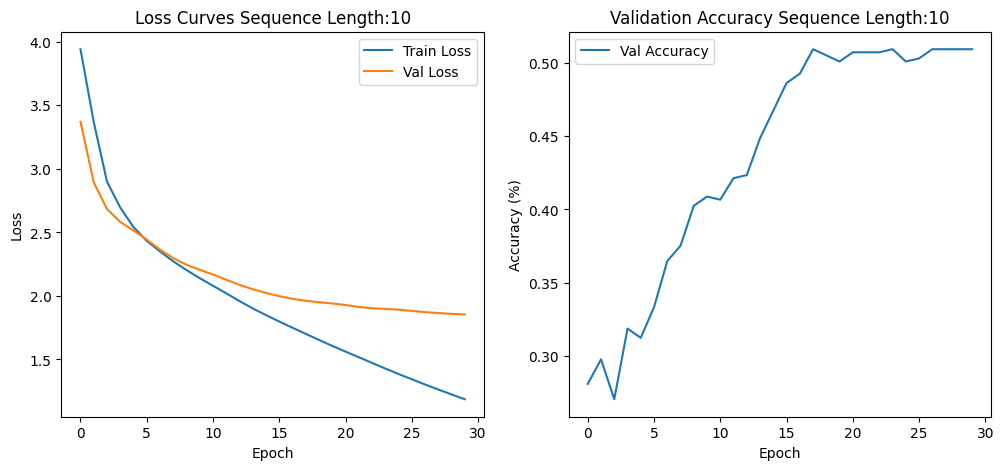

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 10, 100]              4,700
├─RNN: 1-2                               [1, 10, 100]              20,200
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 29,647
Trainable params: 29,647
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.21
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.12
Estimated Total Size (MB): 0.14
Epoch 0, Loss: 3.9008, Val Accuracy: 0.1832, Val Loss: 3.3952
Epoch 1, Loss: 3.3324, Val Accuracy: 0.2632, Val Loss: 2.9466
Epoch 2, Loss: 2.8518, Val Accuracy: 0.2568, Val Loss: 2.7485
Epoch 3, Loss: 2.6313, Val Accuracy: 0.2611, Val Loss: 2.6623
Epoch 4, Loss: 2.5039, Val Accuracy: 0.3032, Val Loss: 2.5860
Epoch 5, Loss: 2.3885, Val Accuracy: 0.2947, Val Loss: 2.5364
Epoch 6, Loss: 2.3080, Val Accuracy: 0

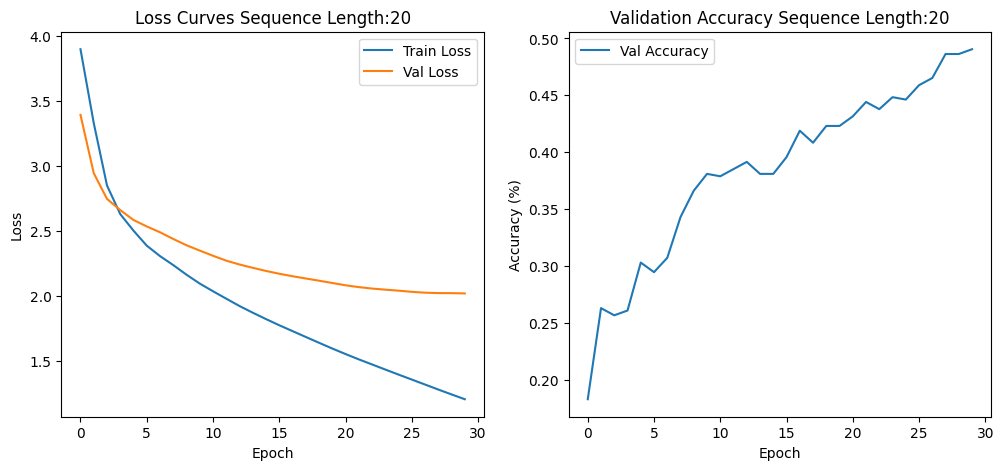

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─RNN: 1-2                               [1, 20, 100]              20,200
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 29,647
Trainable params: 29,647
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.12
Estimated Total Size (MB): 0.15
Epoch 0, Loss: 3.8937, Val Accuracy: 0.2114, Val Loss: 3.3916
Epoch 1, Loss: 3.3491, Val Accuracy: 0.2241, Val Loss: 2.9720
Epoch 2, Loss: 2.8589, Val Accuracy: 0.2135, Val Loss: 2.8349
Epoch 3, Loss: 2.6669, Val Accuracy: 0.2326, Val Loss: 2.7338
Epoch 4, Loss: 2.5388, Val Accuracy: 0.2833, Val Loss: 2.6623
Epoch 5, Loss: 2.4393, Val Accuracy: 0.2854, Val Loss: 2.6115
Epoch 6, Loss: 2.3583, Val Accuracy: 0

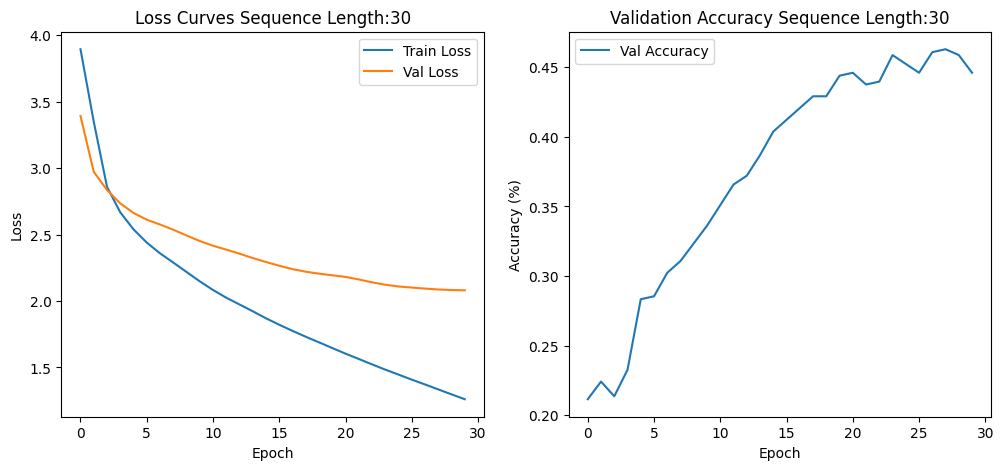

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 30, 100]              4,700
├─RNN: 1-2                               [1, 30, 100]              20,200
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 29,647
Trainable params: 29,647
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.62
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.12
Estimated Total Size (MB): 0.17


In [10]:
run("RNN")

Epoch 0, Loss: 3.8556, Val Accuracy: 0.2411, Val Loss: 3.5907
Epoch 1, Loss: 3.6015, Val Accuracy: 0.2600, Val Loss: 3.2042
Epoch 2, Loss: 3.2296, Val Accuracy: 0.2600, Val Loss: 2.8994
Epoch 3, Loss: 2.9381, Val Accuracy: 0.2348, Val Loss: 2.8289
Epoch 4, Loss: 2.8468, Val Accuracy: 0.2537, Val Loss: 2.7455
Epoch 5, Loss: 2.7354, Val Accuracy: 0.2830, Val Loss: 2.6596
Epoch 6, Loss: 2.6343, Val Accuracy: 0.3061, Val Loss: 2.5825
Epoch 7, Loss: 2.5501, Val Accuracy: 0.3375, Val Loss: 2.5087
Epoch 8, Loss: 2.4721, Val Accuracy: 0.3480, Val Loss: 2.4388
Epoch 9, Loss: 2.3980, Val Accuracy: 0.3543, Val Loss: 2.3752
Epoch 10, Loss: 2.3297, Val Accuracy: 0.3983, Val Loss: 2.3184
Epoch 11, Loss: 2.2654, Val Accuracy: 0.4151, Val Loss: 2.2698
Epoch 12, Loss: 2.2034, Val Accuracy: 0.4172, Val Loss: 2.2306
Epoch 13, Loss: 2.1448, Val Accuracy: 0.4214, Val Loss: 2.1967
Epoch 14, Loss: 2.0886, Val Accuracy: 0.4256, Val Loss: 2.1647
Epoch 15, Loss: 2.0334, Val Accuracy: 0.4277, Val Loss: 2.1343
Ep

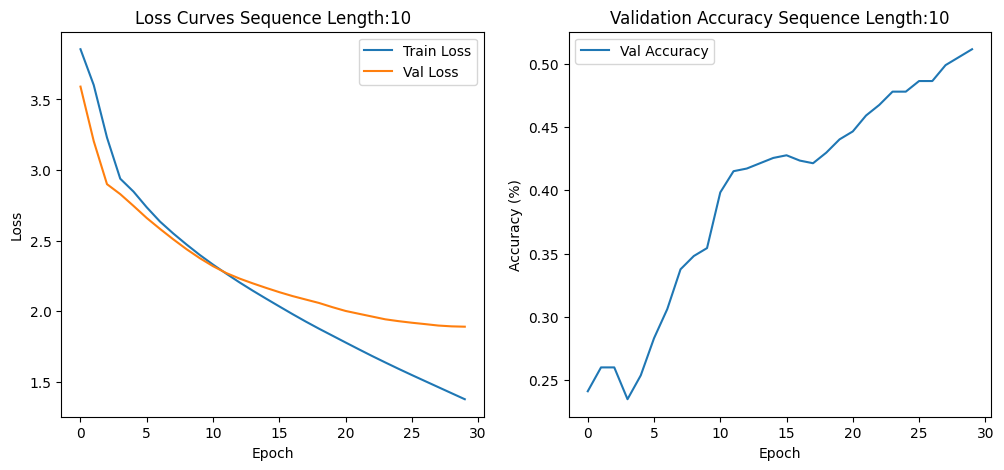

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 47]                   --
├─Embedding: 1-1                         [1, 10, 100]              4,700
├─LSTM: 1-2                              [1, 10, 100]              80,800
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 90,247
Trainable params: 90,247
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.82
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.36
Estimated Total Size (MB): 0.38
Epoch 0, Loss: 3.8559, Val Accuracy: 0.2232, Val Loss: 3.6404
Epoch 1, Loss: 3.6288, Val Accuracy: 0.2316, Val Loss: 3.3154
Epoch 2, Loss: 3.2926, Val Accuracy: 0.2126, Val Loss: 2.9959
Epoch 3, Loss: 2.9599, Val Accuracy: 0.2168, Val Loss: 2.9132
Epoch 4, Loss: 2.8487, Val Accuracy: 0.2779, Val Loss: 2.8010
Epoch 5, Loss: 2.7036, Val Accuracy: 0.2800, Val Loss: 2.7253
Epoch 6, Loss: 2.5936, Val Accuracy: 0

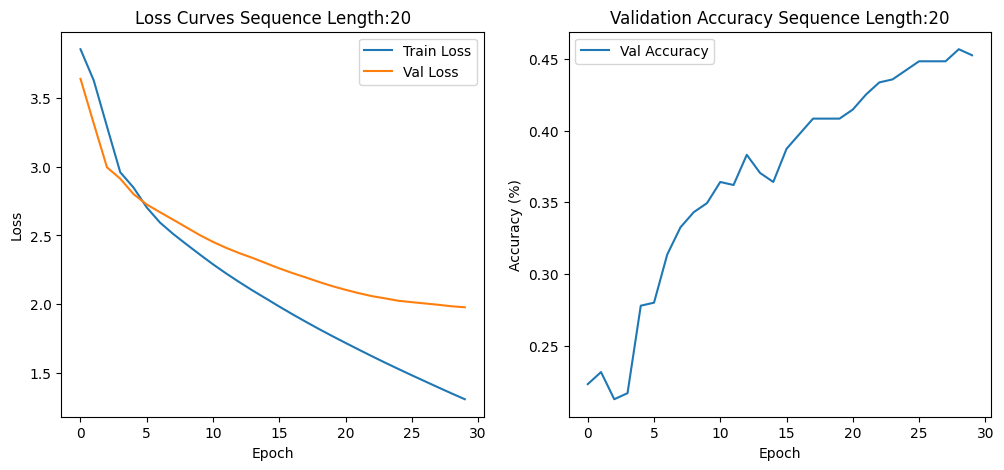

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─LSTM: 1-2                              [1, 20, 100]              80,800
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 90,247
Trainable params: 90,247
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.63
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.36
Estimated Total Size (MB): 0.39
Epoch 0, Loss: 3.8570, Val Accuracy: 0.2051, Val Loss: 3.6070
Epoch 1, Loss: 3.5886, Val Accuracy: 0.1839, Val Loss: 3.2337
Epoch 2, Loss: 3.1840, Val Accuracy: 0.1226, Val Loss: 3.0363
Epoch 3, Loss: 2.9457, Val Accuracy: 0.1903, Val Loss: 2.9237
Epoch 4, Loss: 2.8157, Val Accuracy: 0.2389, Val Loss: 2.8146
Epoch 5, Loss: 2.6877, Val Accuracy: 0.2474, Val Loss: 2.7338
Epoch 6, Loss: 2.5867, Val Accuracy: 0

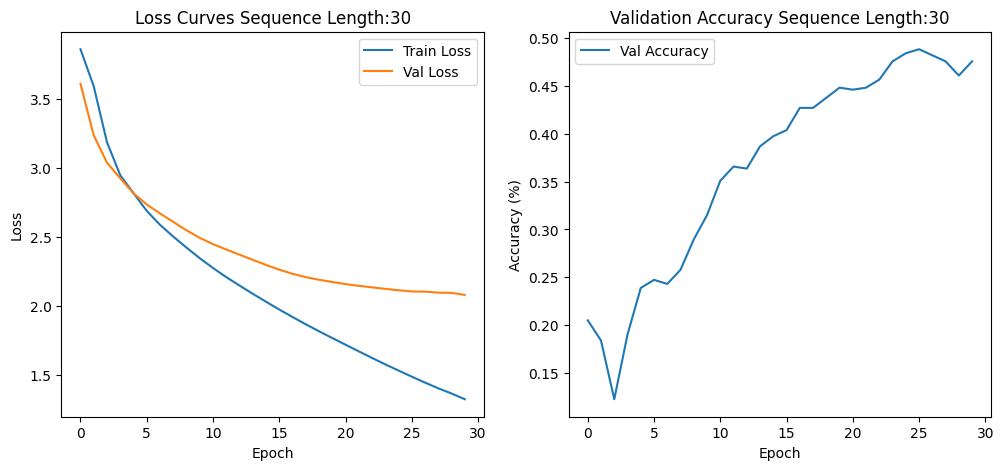

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 47]                   --
├─Embedding: 1-1                         [1, 30, 100]              4,700
├─LSTM: 1-2                              [1, 30, 100]              80,800
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 90,247
Trainable params: 90,247
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.43
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.36
Estimated Total Size (MB): 0.41


In [11]:
run("LSTM")

Epoch 0, Loss: 3.8418, Val Accuracy: 0.2096, Val Loss: 3.3843
Epoch 1, Loss: 3.3911, Val Accuracy: 0.2055, Val Loss: 2.9246
Epoch 2, Loss: 2.9586, Val Accuracy: 0.2180, Val Loss: 2.7659
Epoch 3, Loss: 2.8103, Val Accuracy: 0.2558, Val Loss: 2.6852
Epoch 4, Loss: 2.6903, Val Accuracy: 0.3082, Val Loss: 2.5799
Epoch 5, Loss: 2.5628, Val Accuracy: 0.3333, Val Loss: 2.4899
Epoch 6, Loss: 2.4630, Val Accuracy: 0.3606, Val Loss: 2.4127
Epoch 7, Loss: 2.3801, Val Accuracy: 0.3816, Val Loss: 2.3424
Epoch 8, Loss: 2.3031, Val Accuracy: 0.3941, Val Loss: 2.2844
Epoch 9, Loss: 2.2334, Val Accuracy: 0.4067, Val Loss: 2.2385
Epoch 10, Loss: 2.1710, Val Accuracy: 0.4235, Val Loss: 2.1971
Epoch 11, Loss: 2.1108, Val Accuracy: 0.4151, Val Loss: 2.1578
Epoch 12, Loss: 2.0507, Val Accuracy: 0.4172, Val Loss: 2.1217
Epoch 13, Loss: 1.9908, Val Accuracy: 0.4277, Val Loss: 2.0884
Epoch 14, Loss: 1.9314, Val Accuracy: 0.4423, Val Loss: 2.0570
Epoch 15, Loss: 1.8732, Val Accuracy: 0.4444, Val Loss: 2.0265
Ep

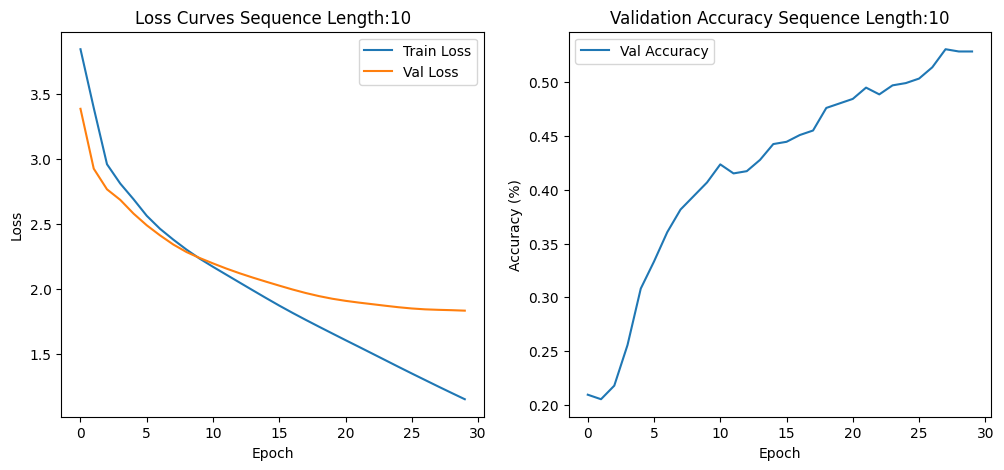

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 10, 100]              4,700
├─GRU: 1-2                               [1, 10, 100]              60,600
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 70,047
Trainable params: 70,047
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.62
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.28
Estimated Total Size (MB): 0.30
Epoch 0, Loss: 3.8701, Val Accuracy: 0.1874, Val Loss: 3.4877
Epoch 1, Loss: 3.4547, Val Accuracy: 0.2084, Val Loss: 3.0700
Epoch 2, Loss: 3.0056, Val Accuracy: 0.2274, Val Loss: 2.8777
Epoch 3, Loss: 2.7856, Val Accuracy: 0.2653, Val Loss: 2.7957
Epoch 4, Loss: 2.6533, Val Accuracy: 0.2884, Val Loss: 2.7326
Epoch 5, Loss: 2.5422, Val Accuracy: 0.2842, Val Loss: 2.6798
Epoch 6, Loss: 2.4505, Val Accuracy: 0

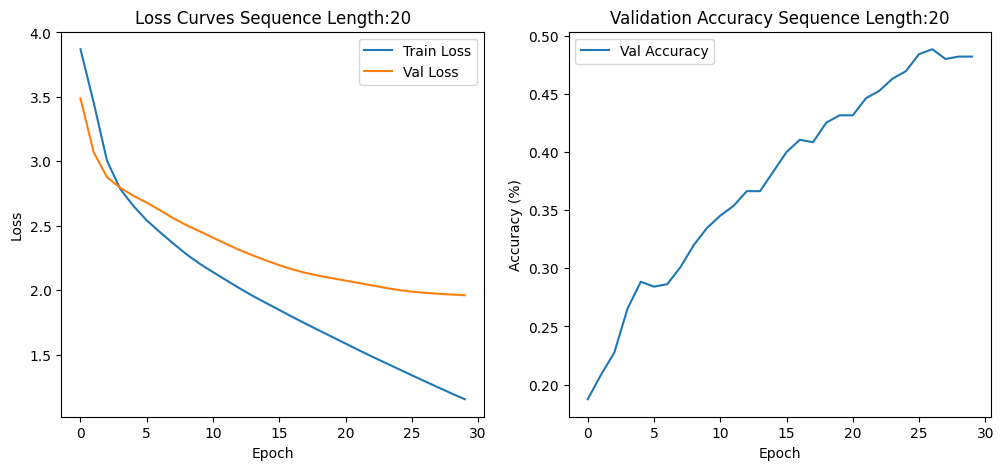

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─GRU: 1-2                               [1, 20, 100]              60,600
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 70,047
Trainable params: 70,047
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.22
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.28
Estimated Total Size (MB): 0.31
Epoch 0, Loss: 3.8568, Val Accuracy: 0.2030, Val Loss: 3.4733
Epoch 1, Loss: 3.4235, Val Accuracy: 0.2030, Val Loss: 3.0805
Epoch 2, Loss: 2.9769, Val Accuracy: 0.2114, Val Loss: 2.9311
Epoch 3, Loss: 2.7817, Val Accuracy: 0.2093, Val Loss: 2.8379
Epoch 4, Loss: 2.6694, Val Accuracy: 0.2178, Val Loss: 2.7219
Epoch 5, Loss: 2.5382, Val Accuracy: 0.2368, Val Loss: 2.6375
Epoch 6, Loss: 2.4358, Val Accuracy: 0

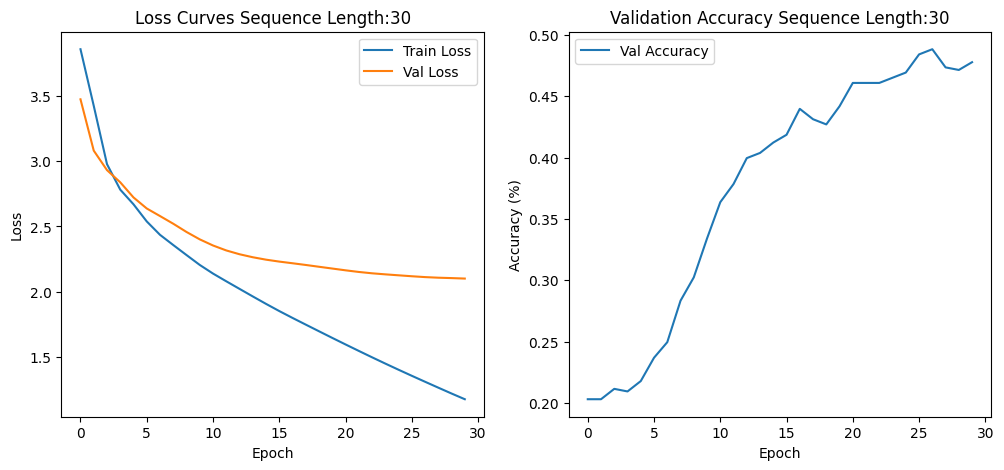

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 30, 100]              4,700
├─GRU: 1-2                               [1, 30, 100]              60,600
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 70,047
Trainable params: 70,047
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.83
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.28
Estimated Total Size (MB): 0.33


In [12]:
run("GRU")